# BoltzGen Mac：旧 12 个 VHH 骨架增强筛选复盘

**证据截点：** analysis/ 生成于 `2026-08-20T05:18:26.929500+00:00`，验证于 `2026-08-20T05:18:26.065770+00:00`。  
**执行语义：** 预训练模型推理与候选生成，不是模型权重训练。  
**主统计口径：** 只包含两个成功的单检查点分支；历史双检查点压力尝试与深度探针均单独陈列。

## 摘要

- 工程合同完整：`24` 次正式尝试全部完成，覆盖 `12` 个骨架与 `2` 个设计检查点；共得到 `48` 个候选和 `96` 个复折叠样本。
- 双检查点同进程压力尝试在设计阶段以返回码 `-2` 结束，同时 swap 增加约 `4.17 GiB`；随后拆成 diverse 与 adherence 两条单检查点分支，正式 24 次尝试均完成。
- 十项默认过滤没有全通过候选：严格存活数为 `0`。主要瓶颈是复合物骨架均方根偏差，其次是复折叠前提示位点覆盖。
- `41/48` 个候选的 Analyze 选样本与 writer 选样本一致；两套公式不同，必须保留这一差异。
- 当前结果只能作为计算候选与流程复盘证据，不能换算为解离常数、实验亲和力、成功率或 GLP-1 型态选择性。
- 7XL0 的 adherence 单检查点近官方深度探针已完整落盘；本 Notebook 在第 9 节单独读取，不并入 48 候选主统计。

## 1. 范围、方法与关键假设

本 Notebook 是可重复执行的技术复盘。它只读取 `analysis/` 规范表、`provenance/enhanced_input_manifest.json` 与必要的只读阶段证据；不会调用模型，不会写入 `runs/`。

### 关键假设

1. `analysis/analysis_manifest.json` 中的 SHA-256 是本次分析输入完整性的冻结依据。
2. 主统计粒度是“单检查点 × 骨架 × 候选”；压力尝试不进入候选分母。
3. 复折叠前提示位点覆盖与复折叠后原子距离是不同阶段、不同几何定义的指标，不能混称。
4. `budget` 只代表排序展示预算，不代表通过全部十项过滤。

In [1]:
# 导入只用于表格、绘图和可重复检查的本地依赖。
from pathlib import Path
import hashlib
import json
import platform
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display

# 抑制与结论无关的第三方弃用提示，保证执行输出干净。
warnings.filterwarnings("ignore")

# 同时兼容“从项目根目录执行”和“从 notebooks/ 目录执行”。
当前目录 = Path.cwd().resolve()
项目根目录候选 = [当前目录, 当前目录.parent]
项目根目录 = next(
    路径 for 路径 in 项目根目录候选
    if (路径 / "analysis" / "validation.json").exists()
)
分析目录 = 项目根目录 / "analysis"

# 锁定中文字体、配色和显示边界，避免图中文字缺失或表格无限展开。
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["PingFang SC", "Heiti SC", "Arial Unicode MS", "DejaVu Sans"],
    "axes.unicode_minus": False,
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.edgecolor": "#425466",
    "axes.labelcolor": "#263645",
    "xtick.color": "#425466",
    "ytick.color": "#425466",
    "text.color": "#1f2d3a",
})
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 180)

# 规范表是所有主结果的唯一数据入口。
表文件 = {
    "候选": "candidates.csv",
    "复折叠样本": "folding_samples.csv",
    "过滤长表": "filter_long.csv",
    "过滤摘要": "filter_summary.csv",
    "热点距离": "hotspot_contacts.csv",
    "检查点摘要": "checkpoint_summary.csv",
    "骨架摘要": "scaffold_summary.csv",
    "骨架检查点摘要": "scaffold_checkpoint_summary.csv",
    "阶段摘要": "stage_summary.csv",
    "阶段资源": "stage_resource_summary.csv",
    "运行": "runs.csv",
    "压力尝试": "stress_attempts.csv",
    "压力阶段": "stress_stage_timing.csv",
    "压力资源": "stress_resource_summary.csv",
}
数据表 = {名称: pd.read_csv(分析目录 / 文件名) for 名称, 文件名 in 表文件.items()}
分析清单 = json.loads((分析目录 / "analysis_manifest.json").read_text(encoding="utf-8"))
运行摘要 = json.loads((分析目录 / "run_summary.json").read_text(encoding="utf-8"))
验证结果 = json.loads((分析目录 / "validation.json").read_text(encoding="utf-8"))
数据字典 = json.loads((分析目录 / "data_dictionary.json").read_text(encoding="utf-8"))
输入清单 = json.loads((项目根目录 / "provenance" / "enhanced_input_manifest.json").read_text(encoding="utf-8"))

# 通过规范 runs 表中的 launch_id 追溯一份正式启动预检，补充硬件和 MPS 探针事实。
代表启动ID = str(数据表["运行"].iloc[0]["launch_id"])
正式预检路径 = 项目根目录 / "provenance" / "preflight" / f"{代表启动ID}.json"
正式预检 = json.loads(正式预检路径.read_text(encoding="utf-8"))

# 统一布尔列，避免 CSV 字符串 "False" 被 Python 当成真值。
def 转布尔(序列):
    return 序列.astype(str).str.strip().str.lower().map({"true": True, "false": False})

for 列名 in ["pass_all_default_filters", "selected_by_budget", "framework_sequence_unchanged", "same_best_sample"]:
    数据表["候选"][列名] = 转布尔(数据表["候选"][列名])
for 列名 in ["passed"]:
    数据表["过滤长表"][列名] = 转布尔(数据表["过滤长表"][列名])
for 列名 in ["heavy_atom_covered_lt8a", "ca_covered_lt8a"]:
    数据表["热点距离"][列名] = 转布尔(数据表["热点距离"][列名])

In [2]:
# 逐项复核分析清单摘要，并核对最关键的行数与主键粒度。
def 文件摘要(路径):
    摘要 = hashlib.sha256()
    with 路径.open("rb") as 文件:
        for 数据块 in iter(lambda: 文件.read(1024 * 1024), b""):
            摘要.update(数据块)
    return 摘要.hexdigest()

摘要不一致 = []
for 记录 in 分析清单["artifacts"]:
    文件路径 = 项目根目录 / 记录["path"]
    if 文件摘要(文件路径) != 记录["sha256"]:
        摘要不一致.append(记录["path"])

候选 = 数据表["候选"]
复折叠样本 = 数据表["复折叠样本"]
过滤长表 = 数据表["过滤长表"]
热点距离 = 数据表["热点距离"]

assert 摘要不一致 == []
assert len(候选) == 48 and 候选["candidate_id"].nunique() == 48
assert len(复折叠样本) == 96
assert 复折叠样本.groupby("candidate_id").size().eq(2).all()
assert len(过滤长表) == 480
assert 过滤长表.groupby("candidate_id").size().eq(10).all()
assert len(热点距离) == 96
assert 热点距离.groupby("candidate_id").size().eq(2).all()
assert 验证结果["failed_checks"] == []

完整性表 = pd.DataFrame([
    ["分析清单文件摘要", len(分析清单["artifacts"]), "全部匹配"],
    ["唯一候选", 候选["candidate_id"].nunique(), "期望 48"],
    ["复折叠样本", len(复折叠样本), "每候选 2 个"],
    ["逐项过滤记录", len(过滤长表), "每候选 10 项"],
    ["复折叠后热点记录", len(热点距离), "每候选 His7、Ala8 各 1 行"],
    ["analysis 验证失败项", len(验证结果["failed_checks"]), "必须为 0"],
], columns=["检查", "观测值", "判定"])
display(完整性表.style.hide(axis="index"))

检查,观测值,判定
分析清单文件摘要,46,全部匹配
唯一候选,48,期望 48
复折叠样本,96,每候选 2 个
逐项过滤记录,480,每候选 10 项
复折叠后热点记录,96,每候选 His7、Ala8 各 1 行
analysis 验证失败项,0,必须为 0


## 2. 环境与输入

主输入是单一正靶几何：PDB 6X18 受体结合态中的 GLP-1(7–36)，共 30 个残基，序列为 `HAEGTFTSDVSSYLEGQAAKEFIAWLVKGR`。`His7` 和 `Ala8` 在截取后的目标链中分别对应 `label_seq_id=1` 与 `2`，它们只是设计提示位点，不是实验结合证据。

12 个 VHH 骨架来自已冻结的旧骨架库；设计区为三个互补决定区，框架区保持不变。运行协议为 `nanobody-anything`，使用实验性 Apple Metal Performance Shaders 分支、单设备、单工作进程、批大小 1、32 位精度和离线资产。

In [3]:
# 汇总实际准备环境与固定执行合同，避免把当前 Notebook 环境冒充成模型运行环境。
运行时 = 输入清单["runtime"]
固定合同 = 输入清单["fixed_execution_contract"]
环境表 = pd.DataFrame([
    ["模型版本基线", 运行时["official_release_baseline"]],
    ["实验分支提交", 运行时["experimental_mps_source_commit"]],
    ["准备时平台", 运行时["platform_at_prepare"]],
    ["冻结预检架构", 正式预检["machine"]],
    ["冻结预检统一内存", f"{正式预检['hardware_memory_bytes'] / 2**30:.1f} GiB"],
    ["冻结预检 PyTorch", 正式预检["torch_probe"]["torch"]],
    ["冻结预检 MPS", f"built={正式预检['torch_probe']['mps_built']}, available={正式预检['torch_probe']['mps_available']}"],
    ["准备时 Python", 运行时["python_at_prepare"].split(" | ")[0]],
    ["本 Notebook Python", sys.version.split()[0]],
    ["协议", 固定合同["protocol"]],
    ["设备合同", 固定合同["device"]],
    ["工作进程 / 批大小", f"{固定合同['num_workers']} / {固定合同['diffusion_batch_size']}"],
    ["离线执行", 固定合同["offline"]],
    ["MPS 进程级内存", "无稳定公开接口，未单独测量"],
], columns=["项目", "记录值"])
display(环境表.style.hide(axis="index"))

项目,记录值
模型版本基线,BoltzGen v0.3.2
实验分支提交,592317f0f5582730b28c144267a15631c07fcb94
准备时平台,macOS-26.2-arm64-arm-64bit
冻结预检架构,arm64
冻结预检统一内存,18.0 GiB
冻结预检 PyTorch,2.13.0
冻结预检 MPS,"built=True, available=True"
准备时 Python,3.12.13
本 Notebook Python,3.12.13
协议,nanobody-anything


In [4]:
# 从冻结输入清单生成目标与骨架明细，不从候选输出反推输入。
目标 = 输入清单["target"]
目标表 = pd.DataFrame([
    ["名称", 目标["name"]],
    ["角色", 目标["role"]],
    ["序列", 目标["sequence"]],
    ["残基数", 目标["residue_count"]],
    ["提示位点", ", ".join(目标["binding_hint_biological_identity"])],
    ["C 端酰胺原子级验证", 目标["terminal_amide_atomically_verified"]],
    ["结构文件", 目标["path"]],
    ["SHA-256", 目标["sha256"]],
], columns=["字段", "值"])
display(目标表.style.hide(axis="index"))

骨架表 = pd.DataFrame(输入清单["scaffold_population"]["records"])[[
    "selection_rank", "candidate_id", "pdb_code", "role", "method",
    "resolution_a", "r_free", "heavy_species", "framework_cluster_id",
    "variable_length_aa", "cdr1_length_aa", "cdr2_length_aa", "cdr3_length_aa"
]].rename(columns={
    "selection_rank": "筛选排序", "candidate_id": "骨架ID", "pdb_code": "PDB",
    "role": "角色", "method": "方法", "resolution_a": "分辨率(Å)",
    "r_free": "R-free", "heavy_species": "来源物种", "framework_cluster_id": "框架簇",
    "variable_length_aa": "VHH长度", "cdr1_length_aa": "CDR1长度",
    "cdr2_length_aa": "CDR2长度", "cdr3_length_aa": "CDR3长度"
})
display(骨架表.style.hide(axis="index").format({"分辨率(Å)": "{:.3f}", "R-free": "{:.4f}"}))

字段,值
名称,GLP-1(7-36) receptor-bound geometry from PDB 6X18
角色,positive_target_geometry_only
序列,HAEGTFTSDVSSYLEGQAAKEFIAWLVKGR
残基数,30
提示位点,"His7, Ala8"
C 端酰胺原子级验证,False
结构文件,inputs/target/6X18_GLP1_7-36_geometry.cif
SHA-256,11b82b2633793e6799f1d56c19a88fd52828bec5d26d9366801753dfa72d2d53


筛选排序,骨架ID,PDB,角色,方法,分辨率(Å),R-free,来源物种,框架簇,VHH长度,CDR1长度,CDR2长度,CDR3长度
1,pdb_00007xl0-A,7XL0,PRIMARY,XRAY,1.700,0.1963,lama glama,FWC0109,121,8,7,15
2,pdb_00006apo-A,6APO,PRIMARY,XRAY,1.168,0.1728,lama glama,FWC0077,116,8,7,11
3,pdb_00008v9x-A,8V9X,PRIMARY,XRAY,1.550,0.2181,camelidae,FWC0211,113,8,7,7
4,pdb_00006xxo-A,6XXO,PRIMARY,XRAY,1.500,0.1832,camelus dromedarius,FWC0115,124,8,8,17
5,pdb_00005l21-B,5L21,PRIMARY,XRAY,1.680,0.2050,vicugna pacos,FWC0060,118,12,10,5
6,pdb_00008fq7-A,8FQ7,PRIMARY,XRAY,1.400,0.2108,camelus dromedarius,FWC0180,118,8,8,11
7,pdb_00008e2n-B,8E2N,PRIMARY,XRAY,1.100,0.2126,vicugna pacos,FWC0168,127,8,11,17
8,pdb_00006xym-A,6XYM,PRIMARY,XRAY,1.200,0.1982,lama glama,FWC0117,137,8,19,19
9,pdb_00008im0-B,8IM0,PRIMARY,XRAY,1.310,0.1896,camelus bactrianus,FWC0191,121,8,7,15
10,pdb_00003tpk-A,3TPK,PRIMARY,XRAY,1.300,0.1761,camelidae,FWC0017,120,8,8,14


## 3. 压力中断与单检查点分支拆分

最初的 `balanced_all12` 压力档位计划在同一设计阶段依次使用 diverse 与 adherence 两个大型检查点。该尝试只完成了 3 个部分设计文件，设计阶段返回码为 `-2`。证据中没有 Python `KeyboardInterrupt` 标志，也没有足够证据把它定性为某一种唯一故障；可以确定的是，同一阶段 swap 增加约 4.17 GiB，且完整流水线没有形成。

工程上随后把它拆成两个独立进程、独立目录、独立日志的单检查点分支；只在分析阶段合并。这一拆分消除了同一 MPS 进程中的设计权重切换。

状态,总耗时(秒),部分设计CIF数,错误类型,错误信息,键盘中断证据,统计解释
FAILED,138.254000,3,RuntimeError,01_design 退出码 -2；详见 $PROJECT_ROOT/data/boltzgen_data/boltzgen_mac_enhanced_old12_glp1_20260820/runs/balanced_all12/01_pdb_00007xl0-A/attempt_001/logs/01_design,True,有 KeyboardInterrupt 与返回码 -2 的文件证据；这是受控中断的压力尝试，不是完整主结果，也不据此判定模型算法失败。


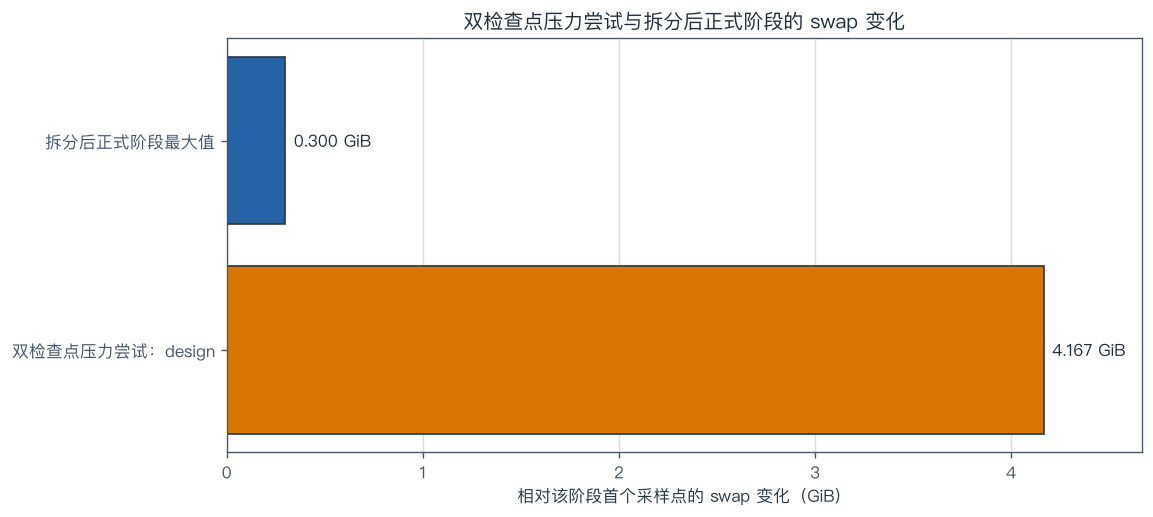

口径,阶段swap变化(GiB),进程树RSS峰值(GiB),系统空闲内存最低值(GiB)
双检查点压力尝试：design,4.167,3.140,0.093
拆分后正式阶段最大值,0.300,3.155,0.089


In [5]:
# 压力尝试只作为工程证据展示，不加入 48 候选主分母。
压力尝试 = 数据表["压力尝试"].copy()
压力阶段 = 数据表["压力阶段"].copy()
压力资源 = 数据表["压力资源"].copy()
display(压力尝试[[
    "status", "elapsed_seconds", "partial_design_cif_count", "error_type",
    "error_message", "keyboard_interrupt_evidence", "interpretation"
]].rename(columns={
    "status": "状态", "elapsed_seconds": "总耗时(秒)",
    "partial_design_cif_count": "部分设计CIF数", "error_type": "错误类型",
    "error_message": "错误信息", "keyboard_interrupt_evidence": "键盘中断证据",
    "interpretation": "统计解释"
}).style.hide(axis="index"))

压力设计 = 压力资源.loc[压力资源["stage"] == "01_design"].iloc[0]
正式资源 = 数据表["阶段资源"]
正式最大_swap = 正式资源.loc[正式资源["swap_stage_delta_gib"].idxmax()]
资源对比 = pd.DataFrame([
    ["双检查点压力尝试：design", 压力设计["swap_stage_delta_gib"], 压力设计["peak_process_tree_rss_gib"], 压力设计["minimum_system_free_gib"]],
    ["拆分后正式阶段最大值", 正式最大_swap["swap_stage_delta_gib"], 正式最大_swap["peak_process_tree_rss_gib"], 正式最大_swap["minimum_system_free_gib"]],
], columns=["口径", "阶段swap变化(GiB)", "进程树RSS峰值(GiB)", "系统空闲内存最低值(GiB)"])

图, 轴 = plt.subplots(figsize=(9.5, 4.2), constrained_layout=True)
颜色 = ["#d97706", "#2563a6"]
横条 = 轴.barh(资源对比["口径"], 资源对比["阶段swap变化(GiB)"], color=颜色, edgecolor="#263645")
轴.set_title("双检查点压力尝试与拆分后正式阶段的 swap 变化")
轴.set_xlabel("相对该阶段首个采样点的 swap 变化（GiB）")
轴.set_xlim(0, max(4.6, 资源对比["阶段swap变化(GiB)"].max() * 1.12))
轴.grid(axis="x", color="#d8dee5", linewidth=0.8)
轴.set_axisbelow(True)
轴.bar_label(横条, fmt="%.3f GiB", padding=5, fontsize=10)
plt.show()
display(资源对比.style.hide(axis="index").format(precision=3))

检查点,骨架数,候选数,复折叠样本数,十项全通过,展示预算项,中位设计-靶标iPTM,中位设计pTM,中位复合物RMSD(Å),复折叠前提示位点阳性,两套最佳样本一致数
骨架遵循检查点,12,24,48,0,12,0.332,0.731,9.087,4,22
多样性检查点,12,24,48,0,12,0.339,0.711,8.518,13,19


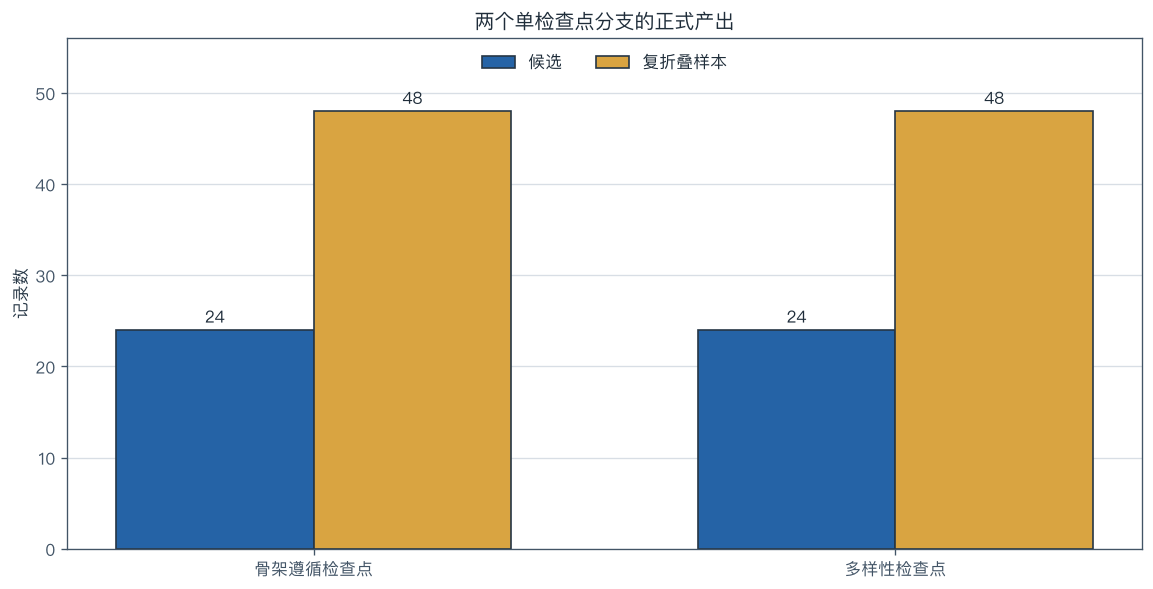

In [6]:
# 两个正式分支使用相同骨架和采样合同，仅设计检查点不同。
检查点摘要 = 数据表["检查点摘要"].copy().sort_values("checkpoint")
展示列 = [
    "checkpoint_label_cn", "scaffold_count", "candidate_count", "folding_sample_count",
    "filter_survivors", "budget_items", "median_design_to_target_iptm",
    "median_design_ptm", "median_filter_rmsd_a", "prerefold_hotspot_positive",
    "writer_analysis_best_match"
]
display(检查点摘要[展示列].rename(columns={
    "checkpoint_label_cn": "检查点", "scaffold_count": "骨架数",
    "candidate_count": "候选数", "folding_sample_count": "复折叠样本数",
    "filter_survivors": "十项全通过", "budget_items": "展示预算项",
    "median_design_to_target_iptm": "中位设计-靶标iPTM",
    "median_design_ptm": "中位设计pTM", "median_filter_rmsd_a": "中位复合物RMSD(Å)",
    "prerefold_hotspot_positive": "复折叠前提示位点阳性",
    "writer_analysis_best_match": "两套最佳样本一致数"
}).style.hide(axis="index").format(precision=3))

图, 轴 = plt.subplots(figsize=(9.5, 4.8), constrained_layout=True)
横坐标 = np.arange(len(检查点摘要))
宽度 = 0.34
柱1 = 轴.bar(横坐标 - 宽度 / 2, 检查点摘要["candidate_count"], 宽度, label="候选", color="#2563a6", edgecolor="#263645")
柱2 = 轴.bar(横坐标 + 宽度 / 2, 检查点摘要["folding_sample_count"], 宽度, label="复折叠样本", color="#d9a441", edgecolor="#263645")
轴.set_xticks(横坐标, 检查点摘要["checkpoint_label_cn"])
轴.set_ylabel("记录数")
轴.set_title("两个单检查点分支的正式产出")
轴.set_ylim(0, 56)
轴.grid(axis="y", color="#d8dee5", linewidth=0.8)
轴.set_axisbelow(True)
轴.legend(frameon=False, ncol=2, loc="upper center")
轴.bar_label(柱1, padding=3)
轴.bar_label(柱2, padding=3)
plt.show()

## 4. 48 个候选与 96 个复折叠样本

每个“骨架 × 检查点”生成 2 个候选；每个候选复折叠 2 次，因此总计 $12\times2\times2=48$ 个候选、$48\times2=96$ 个复折叠样本。

两套最佳样本公式不同：

$$S_{Analyze}=0.8\,iPTM_{design\rightarrow target}+0.2\,pTM_{design}$$

$$S_{writer}=0.8\,iPTM_{complex}+0.2\,pTM_{complex}$$

`writer CIF` 的坐标来自 writer 公式所选的样本。Analyze 指标用于分析视角的候选比较。两者都只是计算排序分数，不是亲和力。

In [7]:
# 检查每个候选是否严格拥有样本 0 和样本 1，并计算两套选样本的一致率。
每候选样本 = 复折叠样本.groupby("candidate_id").agg(
    样本数=("sample_index", "size"),
    样本索引=("sample_index", lambda 值: tuple(sorted(值.astype(int).tolist()))),
    Analyze选择数=("selected_by_analysis", lambda 值: 转布尔(值).sum()),
    writer选择数=("selected_by_writer", lambda 值: 转布尔(值).sum()),
)
assert 每候选样本["样本数"].eq(2).all()
assert 每候选样本["样本索引"].map(lambda 值: 值 == (0, 1)).all()
assert 每候选样本["Analyze选择数"].eq(1).all()
assert 每候选样本["writer选择数"].eq(1).all()

一致率表 = 候选.groupby("checkpoint_label_cn").agg(
    候选数=("candidate_id", "size"),
    最佳样本一致数=("same_best_sample", "sum"),
).reset_index().rename(columns={"checkpoint_label_cn": "检查点"})
一致率表["一致率"] = 一致率表["最佳样本一致数"] / 一致率表["候选数"]
总计 = pd.DataFrame([{
    "检查点": "总计", "候选数": len(候选),
    "最佳样本一致数": int(候选["same_best_sample"].sum()),
    "一致率": 候选["same_best_sample"].mean()
}])
一致率表 = pd.concat([一致率表, 总计], ignore_index=True)
display(一致率表.style.hide(axis="index").format({"一致率": "{:.1%}"}))

检查点,候选数,最佳样本一致数,一致率
多样性检查点,24,19,79.2%
骨架遵循检查点,24,22,91.7%
总计,48,41,85.4%


## 5. 十项默认过滤

复合物骨架均方根偏差使用下式概括；实际程序在指定原子集合与对齐定义上计算：

$$RMSD=\sqrt{\frac{1}{N}\sum_{i=1}^{N}\lVert \mathbf{x}_i-\mathbf{y}_i\rVert^2}$$

十项过滤采用冻结阈值逐项独立复算。“十项全通过”要求每一项都为真；任意一项失败即不是严格存活候选。`budget` 目录只表示每骨架每检查点选出 1 个展示/排序项，两者不可互换。

顺序,过滤项,运算符,阈值,单位,候选数,通过数,失败数,失败率
1,未知残基 X,<=,0,flag,48,48,0,0.0%
2,复合物骨架均方根偏差,<=,2.5,Å,48,3,45,93.8%
3,VHH 设计区骨架均方根偏差,<=,2.5,Å,48,42,6,12.5%
4,复折叠前 His7/Ala8 提示位点 8 Å 覆盖,>=,0.0001,fraction,48,17,31,64.6%
5,设计区半胱氨酸比例,<=,0,fraction,48,48,0,0.0%
6,设计区丙氨酸比例,<=,0.3,fraction,48,48,0,0.0%
7,设计区甘氨酸比例,<=,0.3,fraction,48,47,1,2.1%
8,设计区谷氨酸比例,<=,0.3,fraction,48,48,0,0.0%
9,设计区亮氨酸比例,<=,0.3,fraction,48,48,0,0.0%
10,设计区缬氨酸比例,<=,0.3,fraction,48,48,0,0.0%


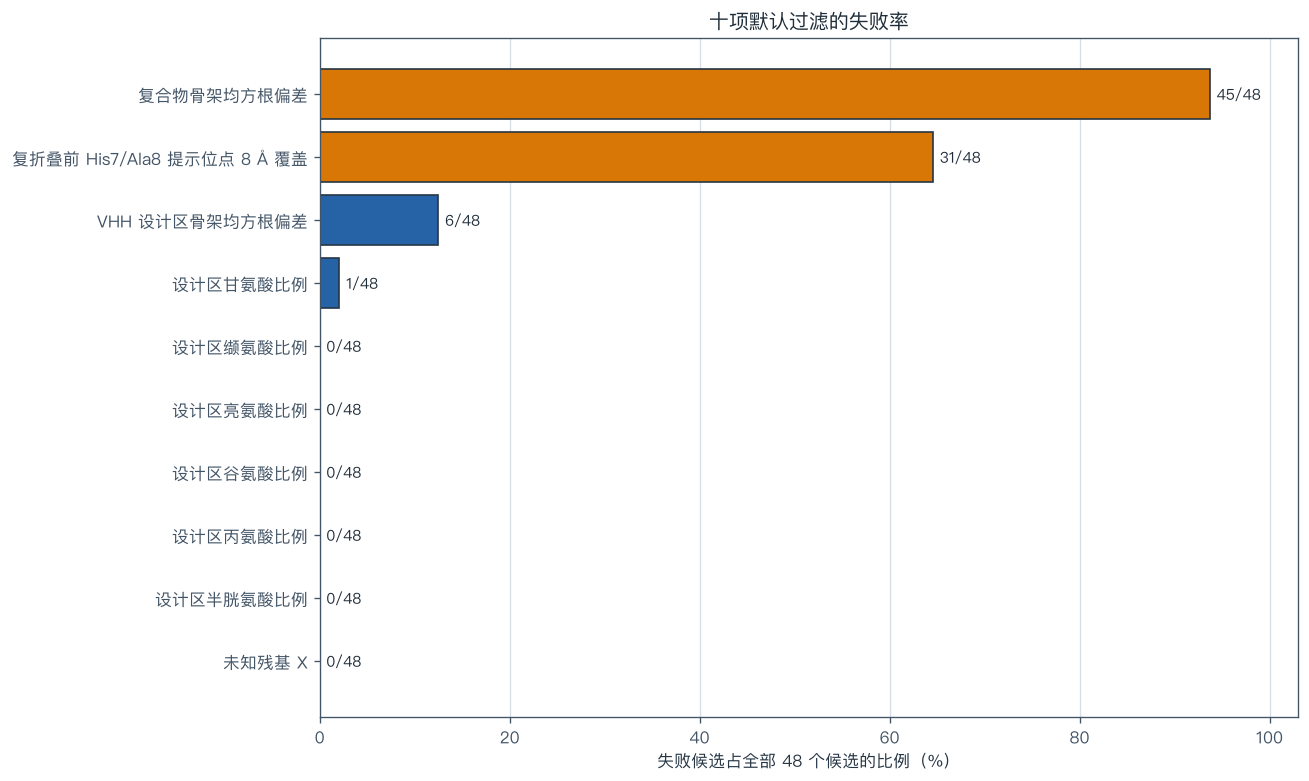

**观察：** 严格通过为 **0/48**；展示预算项为 **24/48**。复合物 RMSD 失败 45/48，复折叠前提示位点覆盖失败 31/48。

In [8]:
# 表格保留阈值、单位和分母；图形按固定顺序展示失败率。
过滤摘要 = 数据表["过滤摘要"].copy().sort_values("filter_order")
过滤展示 = 过滤摘要[[
    "filter_order", "filter_label_cn", "operator", "threshold", "unit",
    "candidate_count", "passed_count", "failed_count", "failure_rate"
]].rename(columns={
    "filter_order": "顺序", "filter_label_cn": "过滤项", "operator": "运算符",
    "threshold": "阈值", "unit": "单位", "candidate_count": "候选数",
    "passed_count": "通过数", "failed_count": "失败数", "failure_rate": "失败率"
})
display(过滤展示.style.hide(axis="index").format({"阈值": "{:.3g}", "失败率": "{:.1%}"}))

图, 轴 = plt.subplots(figsize=(10.8, 6.4), constrained_layout=True)
绘图表 = 过滤摘要.sort_values("failure_rate", ascending=True)
颜色 = ["#d97706" if 值 > 0.5 else "#2563a6" for 值 in 绘图表["failure_rate"]]
横条 = 轴.barh(绘图表["filter_label_cn"], 绘图表["failure_rate"] * 100, color=颜色, edgecolor="#263645")
轴.set_title("十项默认过滤的失败率")
轴.set_xlabel("失败候选占全部 48 个候选的比例（%）")
轴.set_xlim(0, 103)
轴.grid(axis="x", color="#d8dee5", linewidth=0.8)
轴.set_axisbelow(True)
轴.bar_label(横条, labels=[f"{失败}/{总数}" for 失败, 总数 in zip(绘图表["failed_count"], 绘图表["candidate_count"])], padding=4, fontsize=9)
plt.show()

严格通过数 = int(候选["pass_all_default_filters"].sum())
预算项数 = int(候选["selected_by_budget"].sum())
assert 严格通过数 == 0 and 预算项数 == 24
display(Markdown(
    f"**观察：** 严格通过为 **{严格通过数}/48**；展示预算项为 **{预算项数}/48**。"
    f"复合物 RMSD 失败 {int(过滤摘要.loc[过滤摘要['filter_order'].eq(2), 'failed_count'].iloc[0])}/48，"
    f"复折叠前提示位点覆盖失败 {int(过滤摘要.loc[过滤摘要['filter_order'].eq(4), 'failed_count'].iloc[0])}/48。"
))

## 6. His7 / Ala8 热点提示的正确语义

`bindsite_under_8rmsd` 是复折叠前设计结构上的 token-center 覆盖比例。对 His7 与 Ala8 两个提示位点，可写成：

$$C_{pre}=\frac{1}{2}\sum_{h\in\{His7,Ala8\}}\mathbf{1}\!\left[d_{token}(h,VHH_{design})<8\,\text{Å}\right]$$

因而本轮取值只能是 0、0.5 或 1；默认过滤条件是 $C_{pre}>0$，即至少覆盖一个提示位点。它不是距离矩阵、接触数，也不是复折叠后的几何。

`refold_hotspot_coverage_heavy_fraction_lt8a` 则由本分析从 writer 输出 CIF 独立重算，以复折叠后最小重原子距离定义。两者可以不一致；这不是表格错误，而是阶段与几何口径不同。

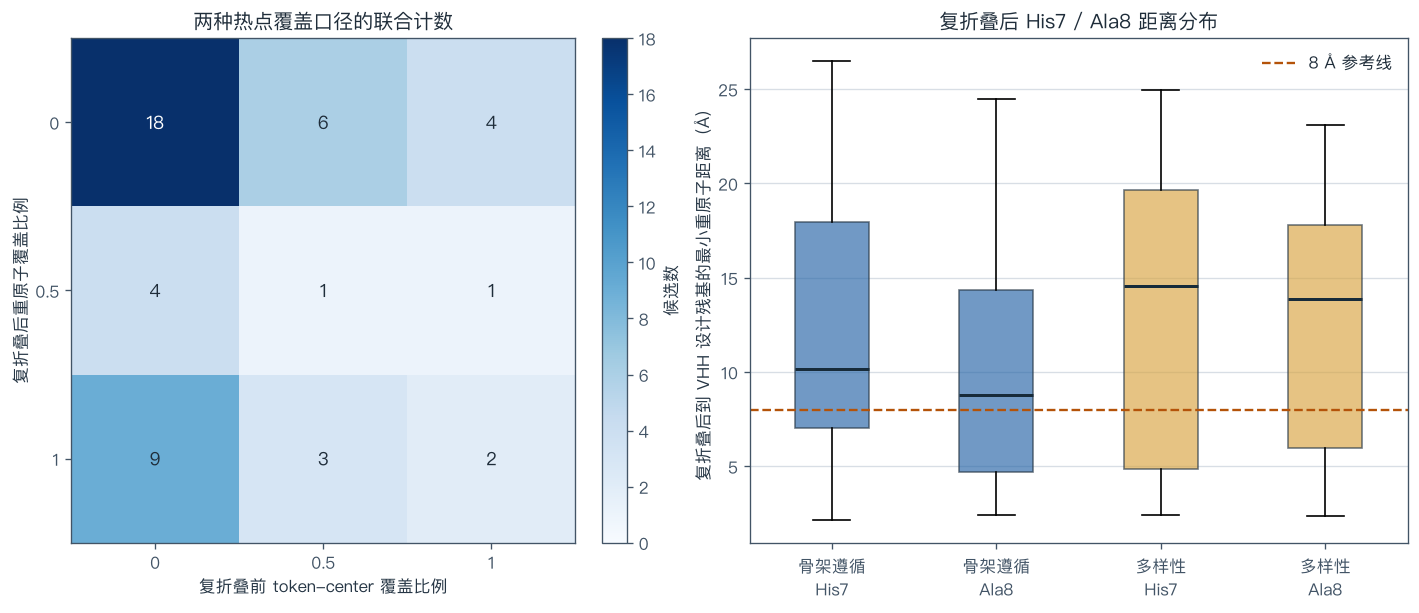

checkpoint,hotspot_biological_name,候选数,重原子小于8Å,Cα小于8Å,重原子距离中位数Å
design_adherence,Ala8,24,12,6,8.777
design_adherence,His7,24,7,3,10.137
design_diverse,Ala8,24,8,5,13.846
design_diverse,His7,24,7,5,14.578


In [9]:
# 左图显示两种覆盖口径的联合计数；右图显示复折叠后独立重原子距离分布。
覆盖顺序 = [0.0, 0.5, 1.0]
联合计数 = pd.crosstab(
    候选["refold_hotspot_coverage_heavy_fraction_lt8a"],
    候选["prerefold_hotspot_coverage_fraction_lt8a"]
).reindex(index=覆盖顺序, columns=覆盖顺序, fill_value=0)

图, 轴组 = plt.subplots(1, 2, figsize=(12.5, 5.0), constrained_layout=True)
热图 = 轴组[0].imshow(联合计数.values, cmap="Blues", vmin=0, vmax=max(1, 联合计数.values.max()))
轴组[0].set_xticks(range(3), ["0", "0.5", "1"])
轴组[0].set_yticks(range(3), ["0", "0.5", "1"])
轴组[0].set_xlabel("复折叠前 token-center 覆盖比例")
轴组[0].set_ylabel("复折叠后重原子覆盖比例")
轴组[0].set_title("两种热点覆盖口径的联合计数")
for 行 in range(3):
    for 列 in range(3):
        值 = int(联合计数.iloc[行, 列])
        轴组[0].text(列, 行, str(值), ha="center", va="center", color="white" if 值 > 联合计数.values.max() / 2 else "#1f2d3a", fontsize=11)
图.colorbar(热图, ax=轴组[0], fraction=0.046, pad=0.04, label="候选数")

热点作图 = 热点距离.copy()
组合 = []
标签 = []
颜色 = []
for 检查点, 检查点标签, 色值 in [
    ("design_adherence", "骨架遵循", "#2563a6"),
    ("design_diverse", "多样性", "#d9a441"),
]:
    for 热点 in ["His7", "Ala8"]:
        组合.append(热点作图.loc[
            (热点作图["checkpoint"] == 检查点) &
            (热点作图["hotspot_biological_name"] == 热点),
            "min_heavy_atom_distance_a"
        ].dropna().to_numpy())
        标签.append(f"{检查点标签}\n{热点}")
        颜色.append(色值)
箱线 = 轴组[1].boxplot(组合, patch_artist=True, tick_labels=标签, showfliers=True)
for 箱体, 色值 in zip(箱线["boxes"], 颜色):
    箱体.set(facecolor=色值, alpha=0.65, edgecolor="#263645")
for 中位线 in 箱线["medians"]:
    中位线.set(color="#172b3a", linewidth=1.8)
轴组[1].axhline(8.0, color="#b45309", linestyle="--", linewidth=1.4, label="8 Å 参考线")
轴组[1].set_ylabel("复折叠后到 VHH 设计残基的最小重原子距离（Å）")
轴组[1].set_title("复折叠后 His7 / Ala8 距离分布")
轴组[1].grid(axis="y", color="#d8dee5", linewidth=0.8)
轴组[1].set_axisbelow(True)
轴组[1].legend(frameon=False)
plt.show()

热点汇总 = 热点作图.groupby(["checkpoint", "hotspot_biological_name"]).agg(
    候选数=("candidate_id", "size"),
    重原子小于8Å=("heavy_atom_covered_lt8a", "sum"),
    Cα小于8Å=("ca_covered_lt8a", "sum"),
    重原子距离中位数Å=("min_heavy_atom_distance_a", "median"),
).reset_index()
display(热点汇总.style.hide(axis="index").format({"重原子距离中位数Å": "{:.3f}"}))

## 7. 阶段耗时与资源边界

耗时按 24 个正式尝试的阶段日志汇总；资源按约 2 秒一次的采样表汇总。`peak_process_tree_rss_gib` 只覆盖 CPU 进程树常驻内存，不能当成独立 MPS 显存。`swap_stage_delta_gib` 以每个阶段首个采样点为基线，因此可比较该阶段内的变化，不等于机器自开机以来的累计 swap。

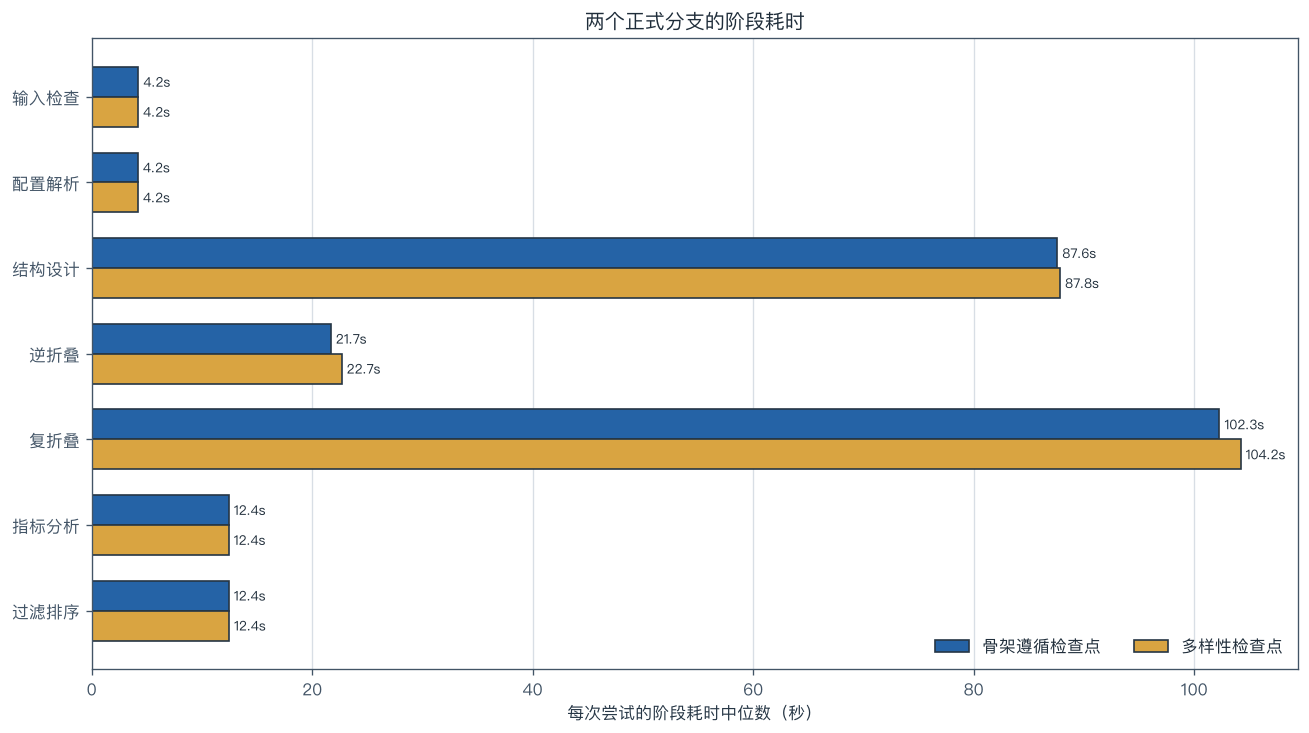

In [10]:
# 阶段顺序是固定流水线顺序，不能按数值排序打乱。
阶段顺序 = ["00_check", "00_configure", "01_design", "02_inverse_folding", "03_folding", "04_analysis", "05_filtering"]
阶段中文 = {
    "00_check": "输入检查", "00_configure": "配置解析", "01_design": "结构设计",
    "02_inverse_folding": "逆折叠", "03_folding": "复折叠",
    "04_analysis": "指标分析", "05_filtering": "过滤排序"
}
阶段摘要 = 数据表["阶段摘要"].copy()
图, 轴 = plt.subplots(figsize=(10.8, 6.0), constrained_layout=True)
纵坐标 = np.arange(len(阶段顺序))
高度 = 0.35
for 偏移, (检查点, 标签, 色值) in zip(
    [-高度 / 2, 高度 / 2],
    [
        ("design_adherence", "骨架遵循检查点", "#2563a6"),
        ("design_diverse", "多样性检查点", "#d9a441"),
    ]
):
    子表 = 阶段摘要.loc[阶段摘要["checkpoint"] == 检查点].set_index("stage").reindex(阶段顺序)
    横条 = 轴.barh(纵坐标 + 偏移, 子表["median_elapsed_seconds"], height=高度, label=标签, color=色值, edgecolor="#263645")
    轴.bar_label(横条, labels=[f"{值:.1f}s" for 值 in 子表["median_elapsed_seconds"]], padding=3, fontsize=8)
轴.set_yticks(纵坐标, [阶段中文[阶段] for 阶段 in 阶段顺序])
轴.invert_yaxis()
轴.set_xlabel("每次尝试的阶段耗时中位数（秒）")
轴.set_title("两个正式分支的阶段耗时")
轴.grid(axis="x", color="#d8dee5", linewidth=0.8)
轴.set_axisbelow(True)
轴.legend(frameon=False, ncol=2, loc="lower right")
plt.show()

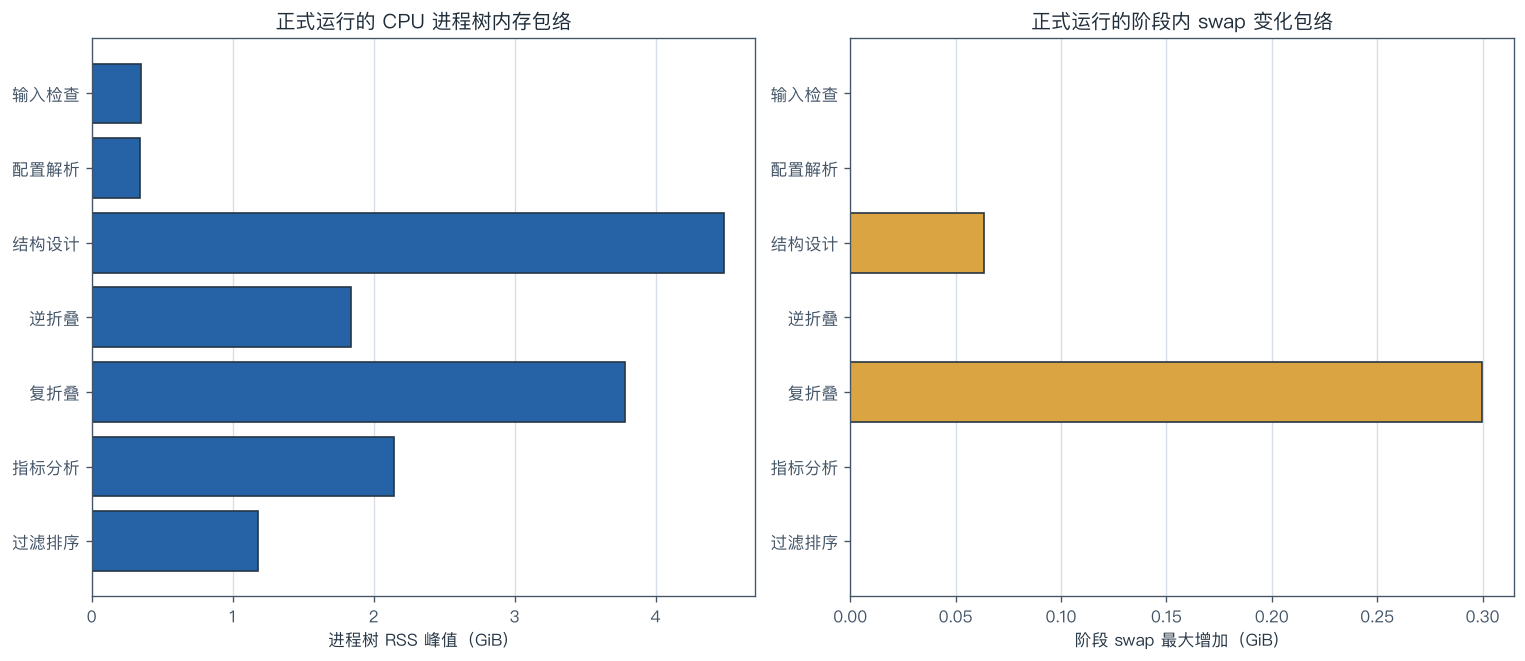

资源指标,观测值,单位
正式阶段最大进程树RSS,4.485,GiB
正式阶段最大swap增加,0.300,GiB
正式阶段最低系统空闲内存,0.046,GiB
正式阶段最低磁盘可用空间,63.098,GiB
压力尝试design阶段swap增加,4.167,GiB


In [11]:
# 资源图展示各阶段在全部正式尝试中的最坏观测值，而不是平均机器状态。
阶段资源 = 数据表["阶段资源"].copy()
资源包络 = 阶段资源.groupby("stage").agg(
    RSS峰值GiB=("peak_process_tree_rss_gib", "max"),
    swap阶段最大增加GiB=("swap_stage_delta_gib", "max"),
    系统空闲内存最低GiB=("minimum_system_free_gib", "min"),
).reindex(阶段顺序).reset_index()

图, 轴组 = plt.subplots(1, 2, figsize=(12.6, 5.4), constrained_layout=True)
轴组[0].barh([阶段中文[值] for 值 in 资源包络["stage"]], 资源包络["RSS峰值GiB"], color="#2563a6", edgecolor="#263645")
轴组[0].invert_yaxis()
轴组[0].set_xlabel("进程树 RSS 峰值（GiB）")
轴组[0].set_title("正式运行的 CPU 进程树内存包络")
轴组[0].grid(axis="x", color="#d8dee5", linewidth=0.8)
轴组[0].set_axisbelow(True)

轴组[1].barh([阶段中文[值] for 值 in 资源包络["stage"]], 资源包络["swap阶段最大增加GiB"], color="#d9a441", edgecolor="#263645")
轴组[1].invert_yaxis()
轴组[1].set_xlabel("阶段 swap 最大增加（GiB）")
轴组[1].set_title("正式运行的阶段内 swap 变化包络")
轴组[1].grid(axis="x", color="#d8dee5", linewidth=0.8)
轴组[1].set_axisbelow(True)
plt.show()

资源极值 = pd.DataFrame([
    ["正式阶段最大进程树RSS", 阶段资源["peak_process_tree_rss_gib"].max(), "GiB"],
    ["正式阶段最大swap增加", 阶段资源["swap_stage_delta_gib"].max(), "GiB"],
    ["正式阶段最低系统空闲内存", 阶段资源["minimum_system_free_gib"].min(), "GiB"],
    ["正式阶段最低磁盘可用空间", 阶段资源["minimum_disk_free_gib"].min(), "GiB"],
    ["压力尝试design阶段swap增加", 压力设计["swap_stage_delta_gib"], "GiB"],
], columns=["资源指标", "观测值", "单位"])
display(资源极值.style.hide(axis="index").format({"观测值": "{:.3f}"}))

## 8. 候选明细表

下方先给出“复盘优先查看”的 12 行，它按十项通过数降序、复合物 RMSD 升序、设计到靶标 iPTM 降序排序。这个顺序只是定位工程矛盾，不是亲和力排行，也不是实验优先级。

随后的可滚动表保留全部 48 个候选。完整、机器可读的主表仍是 `analysis/candidates.csv`。

In [12]:
# 选取既能解释过滤结果、又不把计算分数包装成实验结论的字段。
候选列 = [
    "candidate_id", "pdb_code", "checkpoint_label_cn", "designed_sequence",
    "design_to_target_iptm", "design_ptm", "filter_rmsd_a",
    "prerefold_hotspot_coverage_fraction_lt8a",
    "refold_hotspot_coverage_heavy_fraction_lt8a",
    "computed_filter_pass_count", "failed_filters_cn", "selected_by_budget"
]
候选复盘表 = 候选[候选列].copy().sort_values(
    ["computed_filter_pass_count", "filter_rmsd_a", "design_to_target_iptm"],
    ascending=[False, True, False]
)
候选复盘表 = 候选复盘表.rename(columns={
    "candidate_id": "候选ID", "pdb_code": "骨架PDB", "checkpoint_label_cn": "检查点",
    "designed_sequence": "三个设计区拼接序列", "design_to_target_iptm": "设计-靶标iPTM",
    "design_ptm": "设计pTM", "filter_rmsd_a": "复合物RMSD(Å)",
    "prerefold_hotspot_coverage_fraction_lt8a": "复折叠前提示覆盖",
    "refold_hotspot_coverage_heavy_fraction_lt8a": "复折叠后重原子覆盖",
    "computed_filter_pass_count": "十项通过数", "failed_filters_cn": "失败项",
    "selected_by_budget": "展示预算项"
})
display(候选复盘表.head(12).style.hide(axis="index").format({
    "设计-靶标iPTM": "{:.3f}", "设计pTM": "{:.3f}", "复合物RMSD(Å)": "{:.3f}",
    "复折叠前提示覆盖": "{:.1f}", "复折叠后重原子覆盖": "{:.1f}"
}))

# 使用固定高度的滚动容器，既保留全部 48 行，也不淹没后续章节。
完整表HTML = 候选复盘表.to_html(
    index=False,
    escape=True,
    float_format=lambda 值: f"{值:.3f}",
    classes="候选全表"
)
display(HTML(
    "<div style='max-height:640px;overflow:auto;border:1px solid #ccd6df;border-radius:8px;padding:6px'>"
    + 完整表HTML + "</div>"
))

候选ID,骨架PDB,检查点,三个设计区拼接序列,设计-靶标iPTM,设计pTM,复合物RMSD(Å),复折叠前提示覆盖,复折叠后重原子覆盖,十项通过数,失败项,展示预算项
design_diverse::11_pdb_00008gz6-A_1,8GZ6,多样性检查点,GVSQDFNAIYTSDGSTAAGYKENGELKEV,0.275,0.686,1.468,0.0,0.0,9,复折叠前 His7/Ala8 提示位点 8 Å 覆盖,True
design_adherence::02_pdb_00006apo-A_1,6APO,骨架遵循检查点,SSLFSNSAIWYDGSTAVFSYSTLTSY,0.422,0.679,1.800,0.0,0.0,9,复折叠前 His7/Ala8 提示位点 8 Å 覆盖,True
design_diverse::06_pdb_00008fq7-A_1,8FQ7,多样性检查点,GNVISTYYISYSGGNKWAGKDGKAISF,0.405,0.668,2.227,0.0,0.0,9,复折叠前 His7/Ala8 提示位点 8 Å 覆盖,True
design_diverse::09_pdb_00008im0-B_1,8IM0,多样性检查点,GFTISDYAISSSGSTARYSTASGSSGVADY,0.340,0.767,6.186,0.5,1.0,9,复合物骨架均方根偏差,False
design_diverse::04_pdb_00006xxo-A_0,6XXO,多样性检查点,GFTFTSYGISSSGTTYARSSSIYFSFDESDWDY,0.256,0.671,6.279,0.5,0.0,9,复合物骨架均方根偏差,False
design_diverse::04_pdb_00006xxo-A_1,6XXO,多样性检查点,GFTFTNYGISSSGTTAARYSSGYFSPDFSKFDY,0.341,0.691,6.298,0.5,0.0,9,复合物骨架均方根偏差,True
design_adherence::04_pdb_00006xxo-A_1,6XXO,骨架遵循检查点,GYTFTNYIISPGGSSAAAAKTGANIANFDDYDY,0.384,0.704,6.518,1.0,0.5,9,复合物骨架均方根偏差,True
design_diverse::10_pdb_00003tpk-A_0,3TPK,多样性检查点,GFTISNYAISPDGSYKGRGPNSYNLSEAVY,0.400,0.728,7.707,0.5,1.0,9,复合物骨架均方根偏差,False
design_diverse::02_pdb_00006apo-A_0,6APO,多样性检查点,SSDFSSNGISPSGSTMSINLTTGSYY,0.337,0.709,8.355,1.0,1.0,9,复合物骨架均方根偏差,True
design_adherence::01_pdb_00007xl0-A_0,7XL0,骨架遵循检查点,GLSKPIQAITSSGSTAVKVGSSLFGSGTWY,0.227,0.694,8.670,0.5,0.0,9,复合物骨架均方根偏差,False


候选ID,骨架PDB,检查点,三个设计区拼接序列,设计-靶标iPTM,设计pTM,复合物RMSD(Å),复折叠前提示覆盖,复折叠后重原子覆盖,十项通过数,失败项,展示预算项
design_diverse::11_pdb_00008gz6-A_1,8GZ6,多样性检查点,GVSQDFNAIYTSDGSTAAGYKENGELKEV,0.275,0.686,1.468,0.000,0.000,9,复折叠前 His7/Ala8 提示位点 8 Å 覆盖,True
design_adherence::02_pdb_00006apo-A_1,6APO,骨架遵循检查点,SSLFSNSAIWYDGSTAVFSYSTLTSY,0.422,0.679,1.800,0.000,0.000,9,复折叠前 His7/Ala8 提示位点 8 Å 覆盖,True
design_diverse::06_pdb_00008fq7-A_1,8FQ7,多样性检查点,GNVISTYYISYSGGNKWAGKDGKAISF,0.405,0.668,2.227,0.000,0.000,9,复折叠前 His7/Ala8 提示位点 8 Å 覆盖,True
design_diverse::09_pdb_00008im0-B_1,8IM0,多样性检查点,GFTISDYAISSSGSTARYSTASGSSGVADY,0.340,0.767,6.186,0.500,1.000,9,复合物骨架均方根偏差,False
design_diverse::04_pdb_00006xxo-A_0,6XXO,多样性检查点,GFTFTSYGISSSGTTYARSSSIYFSFDESDWDY,0.256,0.671,6.279,0.500,0.000,9,复合物骨架均方根偏差,False
design_diverse::04_pdb_00006xxo-A_1,6XXO,多样性检查点,GFTFTNYGISSSGTTAARYSSGYFSPDFSKFDY,0.341,0.691,6.298,0.500,0.000,9,复合物骨架均方根偏差,True
design_adherence::04_pdb_00006xxo-A_1,6XXO,骨架遵循检查点,GYTFTNYIISPGGSSAAAAKTGANIANFDDYDY,0.384,0.704,6.518,1.000,0.500,9,复合物骨架均方根偏差,True
design_diverse::10_pdb_00003tpk-A_0,3TPK,多样性检查点,GFTISNYAISPDGSYKGRGPNSYNLSEAVY,0.400,0.728,7.707,0.500,1.000,9,复合物骨架均方根偏差,False
design_diverse::02_pdb_00006apo-A_0,6APO,多样性检查点,SSDFSSNGISPSGSTMSINLTTGSYY,0.337,0.709,8.355,1.000,1.000,9,复合物骨架均方根偏差,True
design_adherence::01_pdb_00007xl0-A_0,7XL0,骨架遵循检查点,GLSKPIQAITSSGSTAVKVGSSLFGSGTWY,0.227,0.694,8.670,0.500,0.000,9,复合物骨架均方根偏差,False


## 9. 7XL0 adherence 单检查点近官方深度探针

冻结规范证据：`analysis/deep_probe_summary.json`；对应运行：`runs/near_official_adherence_7xl0/01_pdb_00007xl0-A/attempt_001`。本节只比较该探针自身与正式 7XL0 adherence 轻量基线，不把深度探针候选并入 48 候选、96 样本或 480 条十项过滤主分母。

“近官方”只表示采样步数接近所记录的官方默认深度；候选量、Apple MPS 实验分支、硬件和统计规模仍不等同于官方 Linux + NVIDIA CUDA 生产基线。

数据域,候选数,复折叠样本数,十项过滤记录数,严格存活数,分母语义
主正式分析,48,96,480,0,48/96/480 独立主分母
7XL0 近官方深度探针,4,4,40,0,4/4/40 独立探针分母


**口径护栏：** 主分析与深度探针是两个独立数据域；不得把 4 个探针候选加进 48 个主候选后计算共同通过率。

阶段,耗时(秒),返回码,合同,资源采样数
00_check,4.2,0,PASS,2
00_configure,4.2,0,PASS,2
01_design,312.5,0,PASS,151
02_inverse_folding,22.7,0,PASS,11
03_folding,196.8,0,PASS,95
04_analysis,12.5,0,PASS,6
05_filtering,12.4,0,PASS,6


阶段,进程树RSS峰值(GiB),系统空闲内存最低(GiB),阶段swap净变化(GiB),阶段swap范围(GiB),磁盘可用最低(GiB)
00_check,0.306,0.245,0.000,0.000,63.034
00_configure,0.318,0.130,0.000,0.000,63.036
01_design,3.112,0.033,0.899,0.938,62.040
02_inverse_folding,1.829,1.616,0.000,0.000,62.041
03_folding,3.528,0.080,-0.023,0.023,62.033
04_analysis,2.081,1.351,0.000,0.000,62.035
05_filtering,1.149,1.097,0.000,0.000,62.033


候选ID,三个设计区拼接序列,设计-靶标iPTM,设计pTM,复合物RMSD(Å),设计区RMSD(Å),复折叠前提示覆盖,十项通过数,失败项,展示预算项
deep_probe::01_pdb_00007xl0-A_0,GSGYTVIAINWDGSTAAAVYNNSTNTYSVY,0.292,0.716,1.868,1.443,0.0,9,复折叠前 His7/Ala8 提示位点 8 Å 覆盖,True
deep_probe::01_pdb_00007xl0-A_2,GLTKTIYAITSDGSTAVVREDADGRLYADY,0.389,0.707,7.527,2.498,0.0,8,复合物骨架均方根偏差；复折叠前 His7/Ala8 提示位点 8 Å 覆盖,False
deep_probe::01_pdb_00007xl0-A_1,GGSFSSYWIWSDGSTATSWYGIFDESYFDY,0.340,0.700,6.768,2.972,0.0,7,复合物骨架均方根偏差；VHH 设计区骨架均方根偏差；复折叠前 His7/Ala8 提示位点 8 Å 覆盖,False
deep_probe::01_pdb_00007xl0-A_3,GGSLSSKGIDSSGNTAVYSSNDVLTSPVLY,0.359,0.680,12.439,3.219,0.0,7,复合物骨架均方根偏差；VHH 设计区骨架均方根偏差；复折叠前 His7/Ala8 提示位点 8 Å 覆盖,False


运行口径,候选数,每候选fold样本数,设计步数,逆折叠步数,复折叠步数,recycling次数,严格存活数,iPTM中位数,pTM中位数,复合物RMSD中位数(Å),复折叠前提示阳性数
轻量 adherence：7XL0,2,2,100,60,100,2,0,0.290,0.717,9.145,2
近官方采样深度：7XL0,4,1,500,200,200,3,0,0.349,0.703,7.148,0


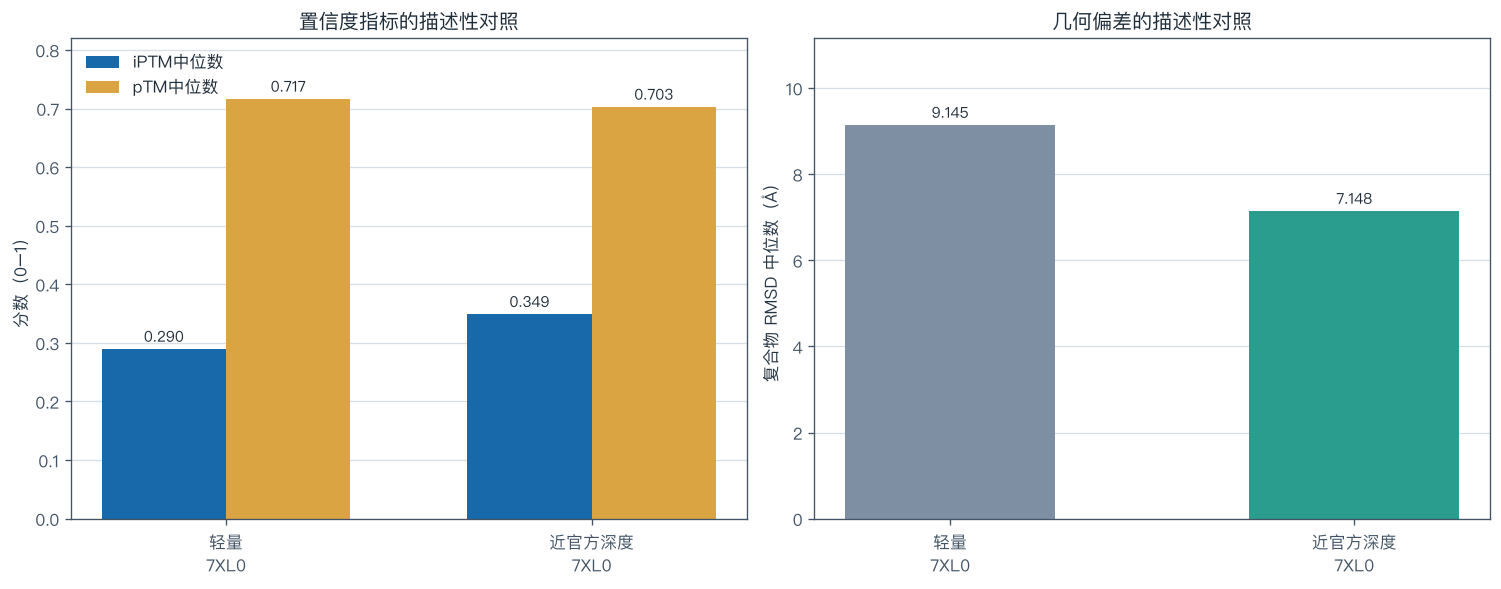

**解释边界：** 轻量组只有 2 个候选、每候选 2 个 fold 样本；深度组有 4 个候选、每候选 1 个 fold 样本。两组严格存活数都为 0，因此图中变化不能解释为采样加深带来显著改善或因果效果。

In [13]:
# 深度探针只读取 analysis/ 中已经冻结、已纳入清单摘要校验的规范表。
深度摘要 = json.loads((分析目录 / "deep_probe_summary.json").read_text(encoding="utf-8"))
深度运行 = pd.read_csv(分析目录 / "deep_probe_runs.csv")
深度候选 = pd.read_csv(分析目录 / "deep_probe_candidates.csv")
深度复折叠样本 = pd.read_csv(分析目录 / "deep_probe_folding_samples.csv")
深度过滤长表 = pd.read_csv(分析目录 / "deep_probe_filter_long.csv")
深度阶段 = pd.read_csv(分析目录 / "deep_probe_stage_timing.csv")
深度资源 = pd.read_csv(分析目录 / "deep_probe_resource_summary.csv")
深度比较 = pd.read_csv(分析目录 / "deep_probe_comparison.csv")

# 将 CSV 布尔值显式归一化，并强制验证深度探针的独立数据合同。
深度候选["pass_all_default_filters"] = 转布尔(深度候选["pass_all_default_filters"])
深度候选["selected_by_budget"] = 转布尔(深度候选["selected_by_budget"])
深度过滤长表["passed"] = 转布尔(深度过滤长表["passed"])
深度计数 = 深度摘要["counts"]
assert 深度摘要["status"] == "COMPLETE"
assert 深度摘要["validation"]["failed_checks"] == []
assert all(深度摘要["validation"]["checks"].values())
assert len(深度运行) == 深度计数["runs"] == 1
assert 深度运行.iloc[0]["status"] == "PIPELINE_COMPLETE"
assert 深度运行.iloc[0]["scope"] == "independent_deep_probe_not_in_main_48"
assert len(深度候选) == 深度候选["candidate_id"].nunique() == 深度计数["candidates"] == 4
assert len(深度复折叠样本) == 深度计数["folding_samples"] == 4
assert 深度复折叠样本.groupby("candidate_id").size().eq(1).all()
assert len(深度过滤长表) == 深度计数["filter_rows"] == 40
assert 深度过滤长表.groupby("candidate_id").size().eq(10).all()
assert len(深度阶段) == 7
assert 深度阶段["return_code"].eq(0).all()
assert 深度阶段["contract_status"].eq("PASS").all()
assert set(候选["candidate_id"]).isdisjoint(set(深度候选["candidate_id"]))

# 两个分母必须分开报告；最后一列明确禁止把它们拼成一个“总体通过率”。
口径对照 = pd.DataFrame([
    ["主正式分析", len(候选), len(复折叠样本), len(过滤长表), int(候选["pass_all_default_filters"].sum()), "48/96/480 独立主分母"],
    ["7XL0 近官方深度探针", len(深度候选), len(深度复折叠样本), len(深度过滤长表), int(深度候选["pass_all_default_filters"].sum()), "4/4/40 独立探针分母"],
], columns=["数据域", "候选数", "复折叠样本数", "十项过滤记录数", "严格存活数", "分母语义"])
display(口径对照.style.hide(axis="index"))
display(Markdown("**口径护栏：** 主分析与深度探针是两个独立数据域；不得把 4 个探针候选加进 48 个主候选后计算共同通过率。"))

# 阶段合同、资源包络和 4 个候选均来自冻结后的规范表。
深度阶段展示 = 深度阶段[["stage", "elapsed_seconds", "return_code", "contract_status", "monitor_sample_count"]].rename(columns={
    "stage": "阶段", "elapsed_seconds": "耗时(秒)", "return_code": "返回码",
    "contract_status": "合同", "monitor_sample_count": "资源采样数"
})
display(深度阶段展示.style.hide(axis="index").format({"耗时(秒)": "{:.1f}"}))

深度资源展示 = 深度资源[[
    "stage", "peak_process_tree_rss_gib", "minimum_system_free_gib",
    "swap_stage_delta_gib", "swap_stage_range_gib", "minimum_disk_free_gib"
]].rename(columns={
    "stage": "阶段", "peak_process_tree_rss_gib": "进程树RSS峰值(GiB)",
    "minimum_system_free_gib": "系统空闲内存最低(GiB)",
    "swap_stage_delta_gib": "阶段swap净变化(GiB)",
    "swap_stage_range_gib": "阶段swap范围(GiB)",
    "minimum_disk_free_gib": "磁盘可用最低(GiB)"
})
display(深度资源展示.style.hide(axis="index").format(precision=3))

深度候选展示 = 深度候选[[
    "candidate_id", "designed_sequence", "design_to_target_iptm", "design_ptm",
    "filter_rmsd_a", "filter_rmsd_design_a",
    "prerefold_hotspot_coverage_fraction_lt8a", "computed_filter_pass_count",
    "failed_filters_cn", "selected_by_budget"
]].rename(columns={
    "candidate_id": "候选ID", "designed_sequence": "三个设计区拼接序列",
    "design_to_target_iptm": "设计-靶标iPTM", "design_ptm": "设计pTM",
    "filter_rmsd_a": "复合物RMSD(Å)", "filter_rmsd_design_a": "设计区RMSD(Å)",
    "prerefold_hotspot_coverage_fraction_lt8a": "复折叠前提示覆盖",
    "computed_filter_pass_count": "十项通过数", "failed_filters_cn": "失败项",
    "selected_by_budget": "展示预算项"
}).sort_values(["十项通过数", "复合物RMSD(Å)"], ascending=[False, True])
display(深度候选展示.style.hide(axis="index").format({
    "设计-靶标iPTM": "{:.3f}", "设计pTM": "{:.3f}",
    "复合物RMSD(Å)": "{:.3f}", "设计区RMSD(Å)": "{:.3f}",
    "复折叠前提示覆盖": "{:.1f}"
}))

# 用单独的比较表呈现轻量 7XL0 与深度探针；两组样本量和 fold 数不同，只作描述性比较。
深度比较展示 = 深度比较[[
    "cohort_label_cn", "candidate_count", "folding_samples_per_candidate",
    "design_sampling_steps", "inverse_fold_sampling_steps", "folding_sampling_steps",
    "design_recycling_steps", "strict_filter_survivors",
    "median_design_to_target_iptm", "median_design_ptm", "median_filter_rmsd_a",
    "prerefold_hotspot_positive"
]].rename(columns={
    "cohort_label_cn": "运行口径", "candidate_count": "候选数",
    "folding_samples_per_candidate": "每候选fold样本数",
    "design_sampling_steps": "设计步数", "inverse_fold_sampling_steps": "逆折叠步数",
    "folding_sampling_steps": "复折叠步数", "design_recycling_steps": "recycling次数",
    "strict_filter_survivors": "严格存活数",
    "median_design_to_target_iptm": "iPTM中位数", "median_design_ptm": "pTM中位数",
    "median_filter_rmsd_a": "复合物RMSD中位数(Å)",
    "prerefold_hotspot_positive": "复折叠前提示阳性数"
})
display(深度比较展示.style.hide(axis="index").format({
    "iPTM中位数": "{:.3f}", "pTM中位数": "{:.3f}", "复合物RMSD中位数(Å)": "{:.3f}"
}))

# 分成两个坐标面板，避免把 0–1 置信度分数与 Å 尺度混画而造成误读。
图, 轴组 = plt.subplots(1, 2, figsize=(12.4, 4.8), constrained_layout=True)
标签 = ["轻量\n7XL0", "近官方深度\n7XL0"]
横坐标 = np.arange(len(深度比较))
宽度 = 0.34
轴组[0].bar(横坐标 - 宽度 / 2, 深度比较["median_design_to_target_iptm"], width=宽度, label="iPTM中位数", color="#1769aa")
轴组[0].bar(横坐标 + 宽度 / 2, 深度比较["median_design_ptm"], width=宽度, label="pTM中位数", color="#d9a441")
轴组[0].set_xticks(横坐标, 标签)
轴组[0].set_ylim(0, 0.82)
轴组[0].set_ylabel("分数（0–1）")
轴组[0].set_title("置信度指标的描述性对照")
轴组[0].legend(frameon=False, loc="upper left")
轴组[0].grid(axis="y", color="#d8dee5", linewidth=0.8)
轴组[0].set_axisbelow(True)
for 容器 in 轴组[0].containers:
    轴组[0].bar_label(容器, fmt="%.3f", padding=3, fontsize=9)

RMSD柱 = 轴组[1].bar(横坐标, 深度比较["median_filter_rmsd_a"], width=0.52, color=["#7e8fa3", "#2a9d8f"])
轴组[1].set_xticks(横坐标, 标签)
轴组[1].set_ylim(0, max(深度比较["median_filter_rmsd_a"]) * 1.22)
轴组[1].set_ylabel("复合物 RMSD 中位数（Å）")
轴组[1].set_title("几何偏差的描述性对照")
轴组[1].grid(axis="y", color="#d8dee5", linewidth=0.8)
轴组[1].set_axisbelow(True)
轴组[1].bar_label(RMSD柱, fmt="%.3f", padding=3, fontsize=9)
plt.show()

display(Markdown(
    "**解释边界：** 轻量组只有 2 个候选、每候选 2 个 fold 样本；深度组有 4 个候选、每候选 1 个 fold 样本。"
    "两组严格存活数都为 0，因此图中变化不能解释为采样加深带来显著改善或因果效果。"
))

## 10. 科学限制与不可推断项

本节直接来自 `analysis/run_summary.json` 与 `analysis/validation.json`，属于结论边界，不是可省略的脚注。

In [14]:
# 原样呈现冻结的科学限制，并附上数据字典禁止推断项。
限制条目 = 运行摘要["scientific_limits"]
限制文本 = "\n".join(f"{序号}. {内容}" for 序号, 内容 in enumerate(限制条目, start=1))
限制文本 += f"\n\n**禁止推断：** {数据字典['forbidden_inference']}"
display(Markdown(限制文本))

1. 这是预训练模型推理与候选生成，不是模型权重训练。
2. 只使用单一 6X18 受体结合态 GLP-1(7–36) 正靶几何。
3. 没有 GLP-1(9–36)、其他反靶或多构象反筛，因此不支持型态选择性结论。
4. 目标 C 端酰胺未完成原子级验证。
5. 所有分数与距离都是计算代理，不支持解离常数、亲和力或实验成功率结论。
6. 实验性 Apple Metal Performance Shaders 分支不等同于官方 Linux + NVIDIA CUDA 基线。
7. 本轮使用 Apple Metal Performance Shaders，且 PYTORCH_ENABLE_MPS_FALLBACK=1 允许不受支持的算子回退到中央处理器；日志未逐算子归因，不能把耗时或数值差异只归因于一种设备。
8. 两种最佳样本公式只在 41/48 个候选上一致；另有 7 个候选选择了不同样本，writer CIF 与 Analyze 指标必须分别解释。
9. 每个骨架每个检查点只有 2 个候选，只适合流程复盘和候选描述。

**禁止推断：** 这些计算结果不得换算为解离常数、亲和力、实验成功率或型态选择性。

## 11. 复盘结论与下一轮

1. **先解决联合失败，不把预算项当阳性。** 48 个候选没有十项全通过；应围绕复合物 RMSD 与提示位点覆盖的联合冲突检查构象、约束、提示位点与排序策略。
2. **深度探针保持单检查点。** `near_official_adherence_7xl0` 的 4 候选、每候选 1 个 fold 样本已完成且工程合同通过；若继续评估 samples=2，应另建独立运行口径，不要恢复同一 MPS 进程的双设计检查点切换。
3. **扩大候选量之前先校准评价。** 对 writer 与 Analyze 选样本不一致的 7 个候选逐一复核，明确后续排序究竟使用哪套几何和公式。
4. **型态选择性必须补反靶与挑战态。** 下一轮至少加入 GLP-1(9–36)、N 端改变/封闭挑战态以及合理多构象；在此之前不能声称活性型态选择性。
5. **计算指标只负责缩小实验空间。** 后续需要独立结构复核、可开发性复核，并以表面等离子体共振或生物层干涉、混合样本捕获和液相色谱-质谱验证真实结合与选择性。

### 复现命令

```bash
$PROJECT_ROOT/data/boltzgen_data/mvp_run_001/env/bin/python scripts/build_notebook.py
```

该命令只重建并执行 Notebook，不会运行 BoltzGen，也不会改写 `runs/`。

In [15]:
# 最终核对 Notebook 中展示的主口径仍与 analysis/ 的冻结摘要一致。
复盘核对 = pd.DataFrame([
    ["正式完整尝试", 运行摘要["counts"]["complete_attempts"], 24],
    ["候选", 运行摘要["counts"]["candidates"], 48],
    ["复折叠样本", 运行摘要["counts"]["folding_samples"], 96],
    ["十项过滤记录", 运行摘要["counts"]["filter_rows"], 480],
    ["严格过滤存活", 运行摘要["counts"]["strict_filter_survivors"], 0],
    ["展示预算项", 运行摘要["counts"]["budget_items"], 24],
], columns=["指标", "Notebook读取值", "冻结期望值"])
复盘核对["一致"] = 复盘核对["Notebook读取值"] == 复盘核对["冻结期望值"]
assert 复盘核对["一致"].all()
display(复盘核对.style.hide(axis="index"))
display(Markdown(f"**Notebook 执行完成。** 分析证据时间：`{分析清单['generated_at_utc']}`；验证评估：`{验证结果['assessment']}`。"))

指标,Notebook读取值,冻结期望值,一致
正式完整尝试,24,24,True
候选,48,48,True
复折叠样本,96,96,True
十项过滤记录,480,480,True
严格过滤存活,0,0,True
展示预算项,24,24,True


**Notebook 执行完成。** 分析证据时间：`2026-08-20T05:18:26.929500+00:00`；验证评估：`READY_FOR_TECHNICAL_REVIEW_WITH_SCIENTIFIC_LIMITS`。